In [125]:
import os
import random
import numpy as np
from tqdm import tqdm
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
from datetime import datetime
import tomllib

In [ ]:
# --- CONFIGURATION ---
IMG_SIZE = 28
SAMPLES_PER_GLYPH = 10  # Starting with 10 for testing
FONT_DIR = "./fonts"
TOML_PATH = "../tp-dataset/categories/typst.toml"

In [127]:
def load_glyphs_from_toml(filepath):
    """Loads and cleans the glyph list from the specified TOML file."""
    if not os.path.exists(filepath):
        print(f"Error: Could not find {filepath}")
        return []
        
    with open(filepath, "rb") as f:
        data = tomllib.load(f)
        
    # Extract the list and strip the '.toml' extension
    raw_list = data.get("wordlist", {}).get("list", [])
    clean_glyphs = [filename.replace(".toml", "") for filename in raw_list]
    
    return clean_glyphs

def load_fonts(font_dir):
    """Loads all TrueType and OpenType fonts from the specified directory."""
    fonts = []
    if not os.path.exists(font_dir):
        os.makedirs(font_dir)
        print(f"Created {font_dir}. Please put your .ttf/.otf files here.")
        return fonts
    
    for file in os.listdir(font_dir):
        if file.endswith((".ttf", ".otf")):
            fonts.append(os.path.join(font_dir, file))
    return fonts

In [128]:
def generate_glyph_image(glyph_text, font_path):
    """Generates a single 28x28 image of a glyph with random augmentations."""
    
    # 1. Draw large to preserve quality during transformations
    base_size = 64
    img = Image.new('L', (base_size, base_size), color=0) # Black background
    draw = ImageDraw.Draw(img)
    
    # Pick a random starting font size
    font_size = random.randint(30, 48)
    try:
        font = ImageFont.truetype(font_path, font_size)
    except IOError:
        print(f"Could not load {font_path}")
        return np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
        
    # Draw text roughly in the center
    bbox = draw.textbbox((0, 0), glyph_text, font=font)
    w = bbox[2] - bbox[0]
    h = bbox[3] - bbox[1]
    
    # Handle fonts that might not render the character properly
    if w == 0 or h == 0: 
        return np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
        
    draw.text(((base_size-w)/2 - bbox[0], (base_size-h)/2 - bbox[1]), glyph_text, fill=255, font=font)
    
    # 2. Random Tilt/Rotation (-20 to +20 degrees)
    angle = random.uniform(-20, 20)
    # Using Resampling.BILINEAR for smooth edges
    img = img.rotate(angle, resample=Image.Resampling.BILINEAR, fillcolor=0)
    
    # 3. Crop tightly to the newly rotated glyph
    bbox = img.getbbox()
    if bbox:
        img = img.crop(bbox)
        
    # 4. Random Stretch / Squish
    stretch_x = random.uniform(0.8, 1.2)
    stretch_y = random.uniform(0.8, 1.2)
    new_w = max(1, int(img.width * stretch_x))
    new_h = max(1, int(img.height * stretch_y))
    
    # Determine scale to fit into the 28x28 canvas while leaving a small random margin
    max_dim = IMG_SIZE - random.randint(2, 10) 
    if new_w > max_dim or new_h > max_dim:
        scale = max_dim / max(new_w, new_h)
        new_w = max(1, int(new_w * scale))
        new_h = max(1, int(new_h * scale))
        
    img = img.resize((new_w, new_h), Image.Resampling.BILINEAR)
    
    # 5. Position randomly on the final 28x28 canvas
    final_img = Image.new('L', (IMG_SIZE, IMG_SIZE), color=0)
    max_x = IMG_SIZE - new_w
    max_y = IMG_SIZE - new_h
    offset_x = random.randint(0, max(0, max_x))
    offset_y = random.randint(0, max(0, max_y))
    
    final_img.paste(img, (offset_x, offset_y))
    
    # 6. Add Noise to mimic pencil/digital artifacts
    arr = np.array(final_img, dtype=np.float32)
    
    # Gaussian noise (base static)
    noise = np.random.normal(loc=0.0, scale=random.uniform(5, 15), size=arr.shape)
    arr = arr + noise
    
    # Speckle noise (simulate spotty ink or bad erasing)
    mask = np.random.rand(*arr.shape)
    arr[mask < 0.02] = 0  # 2% chance a pixel drops to pure black
    
    # Clip back to 0-255 bounds and convert to standard 8-bit unsigned integer
    arr = np.clip(arr, 0, 255).astype(np.uint8)
    
    return arr

Loaded 133 glyphs from ../tp-dataset/categories/typst.toml.
Generating 5000 samples per glyph...


Overall Progress: 100%|██████████| 133/133 [04:22<00:00,  1.97s/it]


Dataset generated! Shape: (665000, 28, 28)


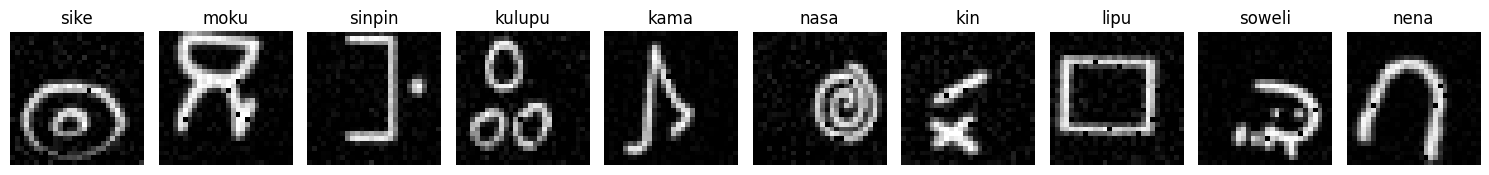

In [ ]:
# --- GENERATE DATASET ---
GLYPHS = load_glyphs_from_toml(TOML_PATH)
fonts_list = load_fonts(FONT_DIR)

if not fonts_list:
    print("Execution paused: Please add fonts to the directory and re-run.")
else:
    X_data = []
    y_data = []

    print(f"Loaded {len(GLYPHS)} glyphs from {TOML_PATH}.")
    
    print(f"Generating {SAMPLES_PER_GLYPH} samples per glyph...")
    for label_idx, glyph in enumerate(tqdm(GLYPHS, desc="Overall Progress")):
        for _ in tqdm(range(SAMPLES_PER_GLYPH), desc=f"Glyph {glyph}", leave=False):
            font = random.choice(fonts_list)
            img_arr = generate_glyph_image(glyph, font)
            X_data.append(img_arr)
            y_data.append(label_idx)
            
    X_data = np.array(X_data)
    y_data = np.array(y_data)
    print(f"Dataset generated! Shape: {X_data.shape}")

    # --- VISUALIZE RESULTS ---
    # 1. Create a 2x10 grid (made the figure slightly taller with figsize)
    fig, axes = plt.subplots(2, 10, figsize=(15, 4))
    
    # 2. Top Row (axes[0, i]): 10 completely random examples
    for i in range(10):
        idx = random.randint(0, len(X_data) - 1)
        axes[0, i].imshow(X_data[idx], cmap='gray')
        axes[0, i].set_title(GLYPHS[y_data[idx]])
        axes[0, i].axis('off')
        
    # 3. Bottom Row (axes[1, i]): 10 variations of a single random glyph
    # Pick one random glyph label ID
    target_glyph_id = random.randint(0, len(GLYPHS) - 1)
    
    # Find all indices in y_data that match this specific glyph
    matching_indices = np.where(y_data == target_glyph_id)[0]
    
    # Randomly select 10 of those indices 
    # (replace=True just ensures it doesn't crash if SAMPLES_PER_GLYPH is currently < 10)
    selected_indices = np.random.choice(
        matching_indices, 
        size=10, 
        replace=(len(matching_indices) < 10)
    )
    
    for i in range(10):
        idx = selected_indices[i]
        axes[1, i].imshow(X_data[idx], cmap='gray')
        axes[1, i].set_title(GLYPHS[y_data[idx]]) # This will be the same word 10 times
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

In [130]:
# --- EXPORT DATASET ---
output_filename = f"data/{SAMPLES_PER_GLYPH/1000}k-{IMG_SIZE}px-{datetime.now().strftime("%m-%d-%H:%M")}.npz"

print(f"Compressing and saving {len(X_data)} images to {output_filename}...")
# We use savez_compressed instead of save to significantly reduce file size
np.savez_compressed(output_filename, X=X_data, y=y_data)
print("Save complete! Your dataset is ready for PyTorch.")

Compressing and saving 665000 images to data/5.0k-28px-03-10-04:13.npz...
Save complete! Your dataset is ready for PyTorch.
